## Méthode des moindre carré

**Objectif:** Importer les données 3D d'un fichier .txt et associer le plan avec la méthode des moindre carrés

# Importer les données
On importe les données du fichier 'points.txt' avec la bibliothèque numpy

In [15]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt('points.txt')

x = data[:,0]
y = data[:,1]
z = data[:,2]

Visualisation du nuage de points en 3D

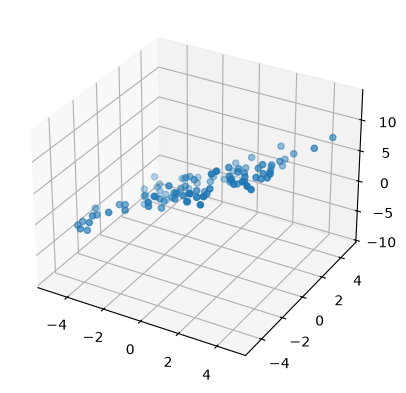

In [16]:
fig=plt.figure()
ax=fig.add_subplot(projection='3d')
ax.scatter(x, y, z)

# Problème mathématique 
L'équation d'un plan est de type 
$$
z = ax+by+c
$$

La méthode des moindre carrés minimise la somme des distances verticales au carré entre les points le plan. Cela revient à minimiser la somme suivante:
$$
S(a,b,c)=\sum_{i=1}^{n} (z_i-(ax_i+by_i+c))^2 
$$
L'écriture sous forme matricielle est:
$$
A = \begin{pmatrix} x_1 & y_1 & 1 \\ \vdots & \vdots & \vdots \\ x_n & y_n & 1 \end{pmatrix}, \qquad p = \begin{pmatrix} a \\ b \\ c \end{pmatrix}, \qquad Z = \begin{pmatrix} z_1 \\ \vdots \\ z_n \end{pmatrix}
$$
Il faut $||Ap-Z||^2 =0 $ ce qui est équivalent à minimiser $S(a,b,c)$ donc :
$$
\nabla S = \left(\frac{\partial S}{\partial a},\ \frac{\partial S}{\partial b},\ \frac{\partial S}{\partial c}\right) = (0,0,0) 
$$ 
Cela revient à chercher $A^\top A \; p = A^\top Z$


# Résolution numérique
Pour résoudre ce problème, la fonction np.linalg.lstsq minimise l'équation $||Ap-Z||^2 =0 $

In [32]:
uns = np.ones(len(x))
A = np.column_stack([x, y, uns])
p, residuals, *_ = np.linalg.lstsq(A, z, rcond=None)

a, b, c = p
print(a,b,c)


1.59532852482399 -0.7640044406530704 2.965806459336923


Affichage du plan et des points

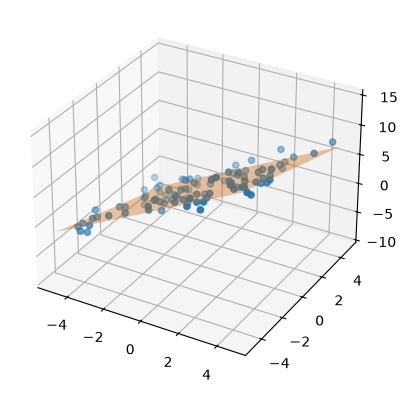

In [27]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x,y,z)

x_lin = np.linspace(x.min(), x.max(), 20)
y_lin = np.linspace(y.min(), y.max(), 20)
X, Y = np.meshgrid(x_lin, y_lin)
Z = a*X + b*Y + c
ax.plot_surface(X, Y, Z, alpha=0.4, color="tab:orange")

# Evaluation du fit du plan
La qualité du fit du plan aux points est donné par 3 données: RMSE / R^2 / Mean residuals

RMSE définit de combien le plan est distant d'un point en moyenne
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n e_i^2}$$

R^2 exprime les variations de z. R^2 = 1 = fit parfait et R^2 = 0 est équivalent à prendre la moyenne des z
$$R^2 = 1 - \frac{\sum e_i^2}{\sum (z_i - \bar z)^2}$$

Mean residuals est la moyenne de chaque écart au plan z

In [ ]:
e = z - A @ p #écarts ei pour chaque point i (équation du plan)
rmse = np.sqrt(np.mean(e**2))

res_2 = np.sum(e**2)
z_zi_2 = np.sum((z-np.mean(z))**2)
r_2 = 1 - res_2/z_zi_2 

mean_res = np.mean(e)

print(f'RMSE = {rmse}')
print(f'R^2 = {r_2}')
print(f'Mean residuals = {mean_res}')

RMSE = 0.9704040525865197
R^2 = 0.9655896788879447
Mean residuals = -7.438494264988549e-16


# Conclusion
Un plan a été modélisé sur un nuage de point 3D afin de un plan avec peu d'écart entre chaque point et ce plan. La méthode des moindre carrés a été utilisé sur python avec la fonction np.linalg.lstsq. Les caractéristiques de ce plan sont les suivantes:

Le R^2 est proche de 1

La distance espérée entre chaque point est le plan z est de 0.97
 
Le plan modélisé peut être considéré comme performant au vu de ces caractéristiques. Reste à déterminer les critères d'applications 